In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/01001
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [11]:
i_stepsize = 11
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  11 0.4500000000000001 0.42500000000000016
-------  22 0.5000000000000002 0.4750000000000002
-------  33 0.5000000000000002 0.5250000000000002
-------  44 0.47500000000000014 0.5750000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  66 0.5250000000000001 0.6500000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  88 0.5500000000000003 0.7250000000000004
-------  99 0.4250000000000001 0.7750000000000005
-------  110 0.5000000000000002 0.8000000000000005
-------  121 0.5750000000000002 0.8250000000000005
-------  132 0.4500000000000001 0.8750000000000006
-------  143 0.5250000000000001 0.9000000000000006


In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13311.435770934964
Gradient descend method:  None
RUN  0 , total integrated cost =  13311.435770934964
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21565.177588309605
Gradient descend method:  None
RUN  0 , total integrated cost =  21565.177588309605
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  33 0.5000000000000002 0.525000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.


In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  11 0.4500000000000001 0.42500000000000016
found solution for  11
-------  22 0.5000000000000002 0.4750000000000002
found solution for  22
-------

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001 0.6250000000000003
converged for  55
-------  66 0.5250000000000001 0.6500000000000004
converged for  66
-------  77 0.4500000000000001 0.7000000000000004
converged for  77
-------  88 0.5500000000000003 0.7250000000000004
converged for  88
-------  99 0.4250000000000001 0.7750000000000005
converged for  99
-------  110 0.5000000000000002 0.8000000000000005
converged for  110
-------  121 0.5750000000

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

file found


In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  80.37403273031657
Gradient descend method:  None
RUN  1 , total integrated cost =  21.758427252002907
RUN  2 , total integrated cost =  21.457049659309025
RUN  3 , total integrated cost =  21.44684696702511
RUN  4 , total integrated cost =  21.437880684054964
RUN  5 , total integrated cost =  21.43121138448088
RUN  6 , total integrated cost =  21.425028646317283
RUN  7 , total integrated cost =  21.42029232158719
RUN  8 , total integrated cost =  21.41453805565218
RUN  9 , total integrated cost =  21.410418903433648
RUN  10 , total integrated cost =  21.399933716714717
RUN  11 , total integrated cost =  21.394907383788095
RUN  12 , total integrated cost =  21.392993429971174
RUN  13 , total integrated cost =  21.391272181263478
RUN  14 , total integrated cost =  21.39076674882552
RUN  15 , total integrated cost =  21.390092217535564
R

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  405 , total integrated cost =  170.80138928750807
Improved over  405  iterations in  81.61870555393398  seconds by  23.464057481196747  percent.
Problem in initial value trasfer:  Vmean_exc -56.67260326733661 -56.672595105658196
weight =  7792.51726965638
set cost params:  1.0 7792.51726965638 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13295.718977929117
Gradient descend method:  None
RUN  1 , total integrated cost =  13255.115350390368
RUN  2 , total integrated cost =  12293.504058961791
RUN  3 , total integrated cost =  12273.508778503665
RUN  4 , total integrated cost =  12264.19368196306
RUN  5 , total integrated cost =  12238.78903433662
RUN  6 , total integrated cost =  12229.477150415129
RUN  7 , total integrated cost =  12204.407512832908
RUN  8 , total integrated cost =  12195.758516978587
RUN  9 , total integrated cost =  12173.405491540456
RUN  10 , total integrated cost =  12164.578988416348
RUN  11 , to

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  7906.009360108691
RUN  1000 , total integrated cost =  7906.009360108691
Improved over  1000  iterations in  156.91069512069225  seconds by  40.53718062759404  percent.
Problem in initial value trasfer:  Vmean_exc -56.67240001238178 -56.672398167061345
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  72.5105438607279
Gradient descend method:  None
RUN  1 , total integrated cost =  16.590568712380584
RUN  2 , total integrated cost =  16.58025642684603
RUN  3 , total integrated cost =  16.577646187976484
RUN  4 , total integrated cost =  16.575266513660246
RUN  5 , total integrated cost =  16.572590068883322
RUN  6 , total integrated cost =  16.570478925654513
RUN  7 , total integrated cost =  16.568525494188563
RUN  8 , total integrated cost =  16.566432153807348
RUN  9 , total integrated cost =  16.56491703459398
RUN  10 , total integrated cost = 

...

Control only changes marginally.
RUN  182 , total integrated cost =  10077.197004948503
Improved over  182  iterations in  32.97295135259628  seconds by  0.10754262426814876  percent.
Problem in initial value trasfer:  Vmean_exc -56.65225844246837 -56.65225933924888
-------  143 0.5250000000000001 0.9000000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  65.75274580360943
Gradient descend method:  None
RUN  1 , total integrated cost =  46.5901676979804
RUN  2 , total integrated cost =  46.58930177668878
RUN  3 , total integrated cost =  46.58830872610546
RUN  4 , total integrated cost =  46.58766121783696
RUN  5 , total integrated cost =  46.586915283580296
RUN  6 , total integrated cost =  46.58641906049248
RUN  7 , total integrated cost =  46.5858092565937
RUN  8 , total integrated cost =  46.58532560809263
RUN  9 , total integrated cost =  46.58468904238217
RUN  10 , total integrated cost =  46.584181949561476
RUN  11 ,

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  320 , total integrated cost =  1074.6978180235958
Improved over  320  iterations in  63.57979905791581  seconds by  0.7258203861001817  percent.
Problem in initial value trasfer:  Vmean_exc -56.70053926666882 -56.7005396273823
weight =  2179.219262168415
set cost params:  1.0 2179.219262168415 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23415.505839437177
Gradient descend method:  None
RUN  1 , total integrated cost =  23392.04363304438
RUN  2 , total integrated cost =  23392.043550334958
RUN  3 , total integrated cost =  23392.04346739608
RUN  4 , total integrated cost =  23392.03771007003
RUN  5 , total integrated cost =  23392.01895030647
RUN  6 , total integrated cost =  23392.008192030502
RUN  7 , total integrated cost =  23392.00808101512
RUN  8 , total integrated cost =  23392.008068446103
RUN  9 , total integrated cost =  23392.008067282623
RUN  10 , total integrated cost =  23392.008067179857
RUN  11 , total

ERROR:root:Problem in initial value trasfer


RUN  16 , total integrated cost =  23392.00806716551
Control only changes marginally.
RUN  16 , total integrated cost =  23392.00806716551
Improved over  16  iterations in  3.5092578902840614  seconds by  0.10035133314136147  percent.
Problem in initial value trasfer:  Vmean_exc -56.7005353158373 -56.70053580756622


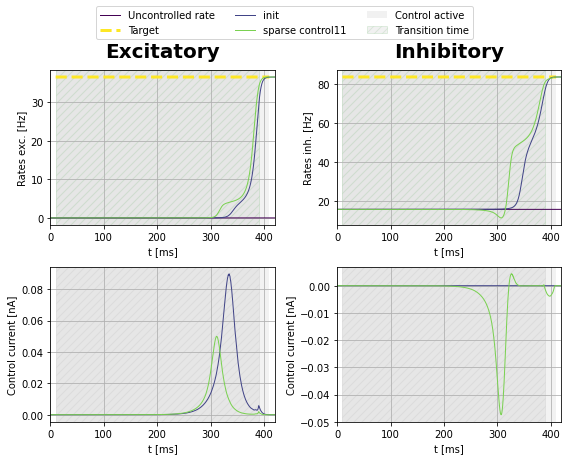

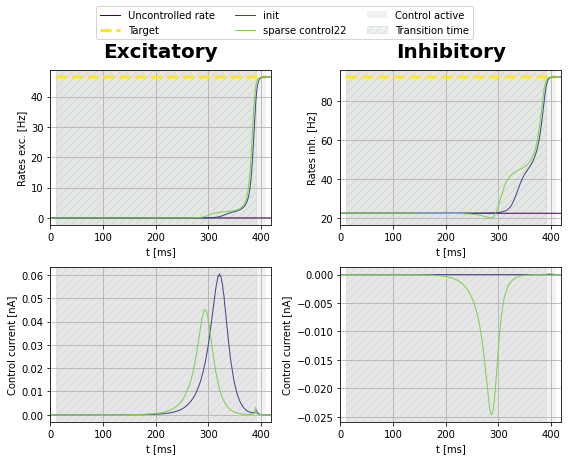

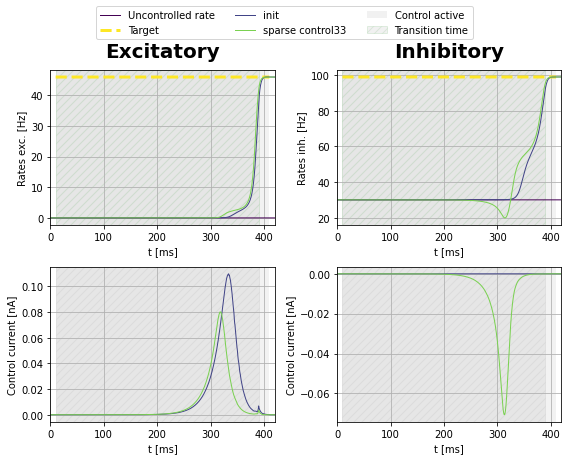

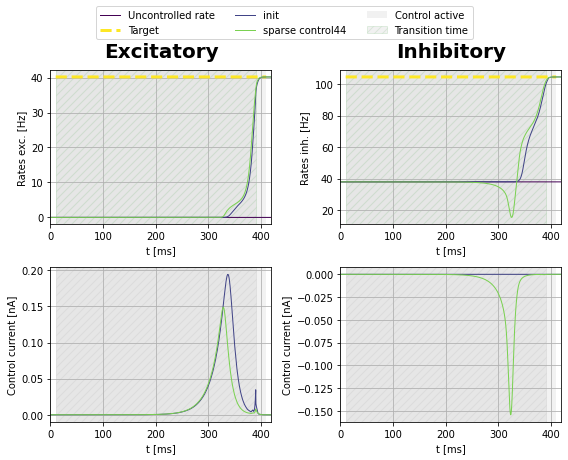

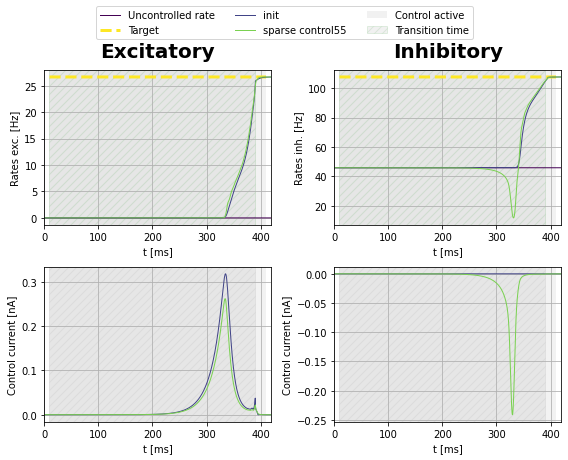

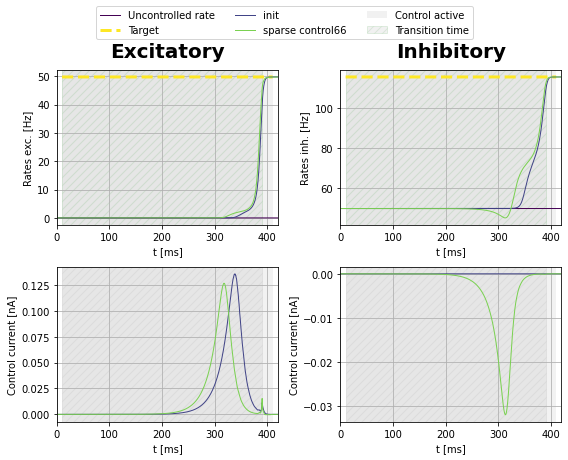

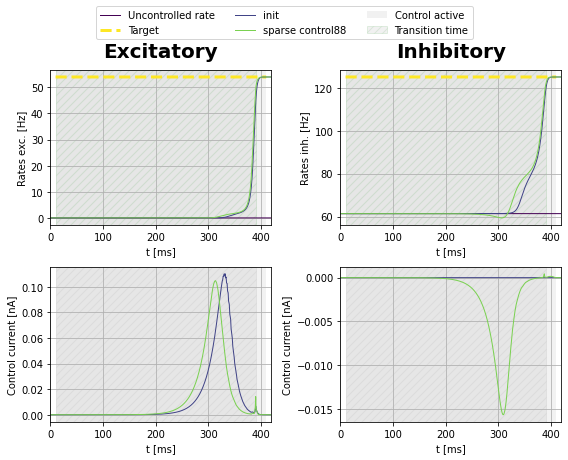

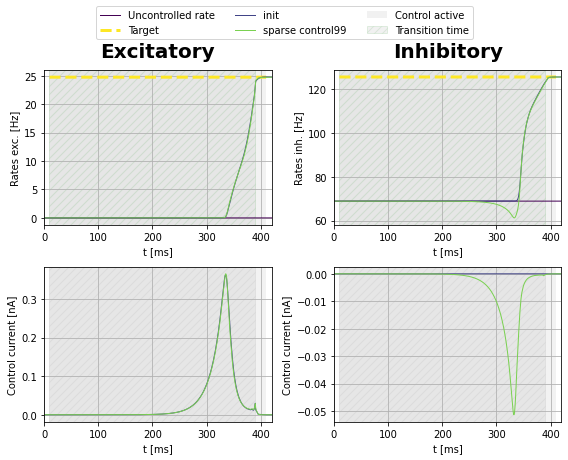

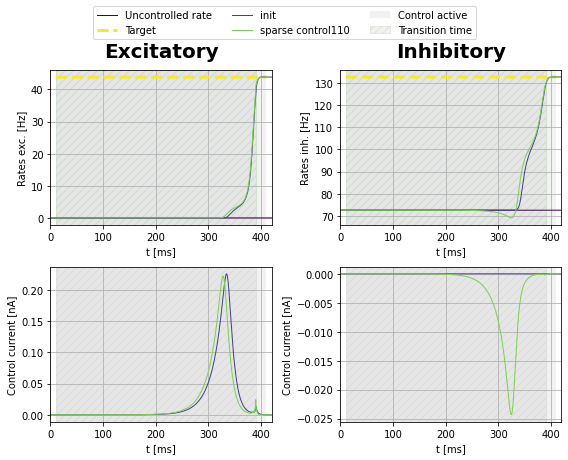

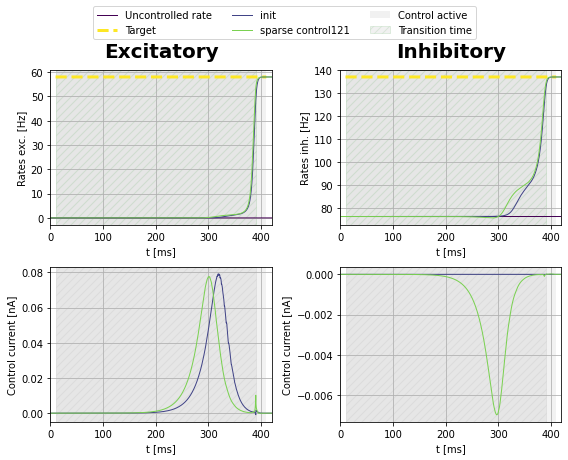

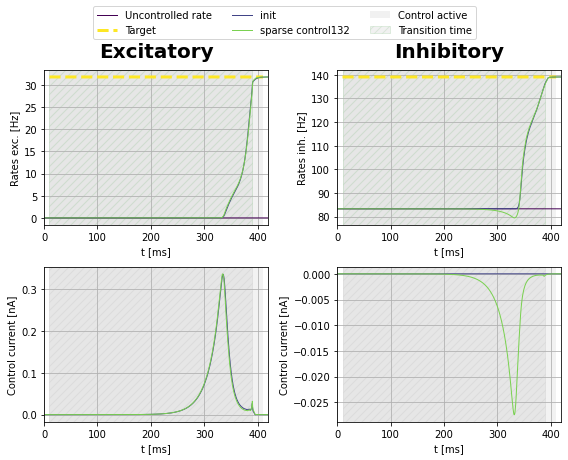

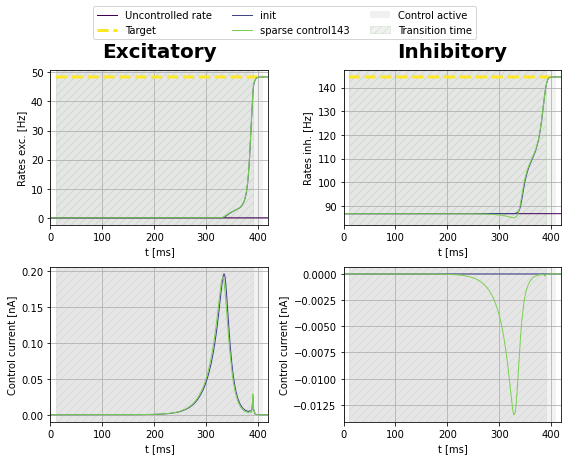

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
no convergence
weight =  13119.347877694181
set cost params:  1.0 13119.347877694181 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13305.641734671066
Gradient descend method:  None
RUN  1 , total integrated cost =  13304.430396106774
RUN  2 , total integrated cost =  13303.517481547402
RUN  3 , total integrated cost =  13302.535567674124
RUN  4 , total integrated cost =  13301.515417966997
RUN  5 , total integrated cost =  13300.255405135109
RUN  6 , total integrated cost =  13299.342507956568
RUN  7 , total integrated cost =  13298.398087749827
RUN  8 , total integrated cost =  13297.397797247871
RUN  9 , total integrated cost =  13296.114242804379
RUN  10 , total integr

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  935 , total integrated cost =  12690.498802342667
Improved over  935  iterations in  143.74634987674654  seconds by  4.623173722808843  percent.
Problem in initial value trasfer:  Vmean_exc -56.67228557735756 -56.67228722772473
-------  22 0.5000000000000002 0.4750000000000002
no convergence
weight =  24237.14980944594
set cost params:  1.0 24237.14980944594 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21563.655063327424
Gradient descend method:  None
RUN  1 , total integrated cost =  21556.144764562643
RUN  2 , total integrated cost =  21512.89125730014
RUN  3 , total integrated cost =  21509.659174379107
RUN  4 , total integrated cost =  21505.56462773526
RUN  5 , total integrated cost =  21504.903943008652
RUN  6 , total integrated cost =  21504.078346156602
RUN  7 , total integrated cost =  21503.01211509313
RUN  8 , total integrated cost =  21502.215475680838
RUN  9 , total integrated cost =  21501.317629151905
R

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  3482 , total integrated cost =  20541.60812265188
Improved over  3482  iterations in  544.0907942857593  seconds by  4.739673945228816  percent.
Problem in initial value trasfer:  Vmean_exc -56.69838537917889 -56.698385446762515
-------  33 0.5000000000000002 0.5250000000000002
no convergence
weight =  7021.900279261143
set cost params:  1.0 7021.900279261143 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21064.30293921237
Gradient descend method:  None
RUN  1 , total integrated cost =  21064.201322374174
RUN  2 , total integrated cost =  21064.20066239369
RUN  3 , total integrated cost =  21064.200593716992
RUN  4 , total integrated cost =  21064.20057653974
RUN  5 , total integrated cost =  21064.200572369144
RUN  6 , total integrated cost =  21064.200571332585
RUN  7 , total integrated cost =  21064.200569969802
RUN  8 , total integrated cost =  21064.200568967684
RUN  9 , total integrated cost =  21064.200568150452


...

RUN  2 , total integrated cost =  24736.45958443587
Control only changes marginally.
RUN  2 , total integrated cost =  24736.45958443587
Improved over  2  iterations in  0.8849255181849003  seconds by  1.4210854715202004e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.70207294681174 -56.702074393480444
-------  88 0.5500000000000003 0.7250000000000004
converged for  88
-------  99 0.4250000000000001 0.7750000000000005
converged for  99
-------  110 0.5000000000000002 0.8000000000000005
converged for  110
-------  121 0.5750000000000002 0.8250000000000005
no convergence
weight =  13522.83808999204
set cost params:  1.0 13522.83808999204 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33629.97122314288
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  33629.97122314288
Control only changes marginally.
RUN  1 , total integrated cost =  33629.97122314288
Improved over  1  iterations in  0.4705793671309948  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.7034381574311 -56.70343782799086
-------  132 0.4500000000000001 0.8750000000000006
converged for  132
-------  143 0.5250000000000001 0.9000000000000006
converged for  143
--------------- 7
[[True, True], [True, False], [True, True], [True, True], [True, False], [False, False], [False, False], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True]]
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001 0.6250000000000003
no convergence


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  24736.45958443587
Control only changes marginally.
RUN  1 , total integrated cost =  24736.45958443587
Improved over  1  iterations in  0.45915674045681953  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70207294681174 -56.702074393480444
-------  88 0.5500000000000003 0.7250000000000004
converged for  88
-------  99 0.4250000000000001 0.7750000000000005
converged for  99
-------  110 0.5000000000000002 0.8000000000000005
converged for  110
-------  121 0.5750000000000002 0.8250000000000005
converged for  121
-------  132 0.4500000000000001 0.8750000000000006
converged for  132
-------  143 0.5250000000000001 0.9000000000000006
converged for  143
--------------- 8
[[True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [False, False], [True, True], [True, True], [True, True], [True, True], [True, False], [True, True], [True, True]]
-------  11 0.4500000000000001 0.42500000000000016
converged fo

In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

file found


In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  11.150766986253874
Gradient descend method:  None
RUN  1 , total integrated cost =  0.9853067161028113
RUN  2 , total integrated cost =  0.9817543552709439
RUN  3 , total integrated cost =  0.9795947771556329
RUN  4 , total integrated cost =  0.977917552136624
RUN  5 , total integrated cost =  0.9768277058289139
RUN  6 , total integrated cost =  0.9760072230951441
RUN  7 , total integrated cost =  0.9754300850464415
RUN  8 , total integrated cost =  0.9750023548670579
RUN  9 , total integrated cost =  0.974677217359411
RUN  10 , total integrated cost =  0.9744325461870555
RUN  11 , total integrated cost =  0.9742265238047428
RUN  12 , total integrated cost =  0.9740763467242776
RUN  13 , total integrated cost =  0.9739471976782629
RUN  14 , total integrated cost =  0.9738521099701077
RUN  15 , total integrated cost =  0.973760836470682

RUN  190 , total integrated cost =  3.006613632908273
RUN  200 , total integrated cost =  3.0066013429860723
RUN  300 , total integrated cost =  3.0064169843770614
RUN  400 , total integrated cost =  3.0063588951486304
RUN  500 , total integrated cost =  3.0063463106852946
RUN  600 , total integrated cost =  3.006268495804296
Control only changes marginally.
RUN  612 , total integrated cost =  3.0062684958041666
Improved over  612  iterations in  38.41991358809173  seconds by  82.40474391219956  percent.
-------  44 0.47500000000000014 0.5750000000000003
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17.699125437644916
Gradient descend method:  None
RUN  1 , total integrated cost =  9.247275319930408
RUN  2 , total integrated cost =  9.241219443482592
RUN  3 , total integrated cost =  9.233889125054631
RUN  4 , total integrated cost =  9.227176778809053
RUN  5 , total integrated cost =  9.218300549363182
RUN  6 , total integrated c

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  822 , total integrated cost =  8.990133445444943
Improved over  822  iterations in  51.62488033622503  seconds by  49.205775860972764  percent.
Problem in initial value trasfer:  Vmean_exc -56.684061857970995 -56.684061870987414
-------  55 0.4250000000000001 0.6250000000000003
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23.31968486376515
Gradient descend method:  None
RUN  1 , total integrated cost =  22.021492384846244
RUN  2 , total integrated cost =  22.018550062967226
RUN  3 , total integrated cost =  22.01441040835221
RUN  4 , total integrated cost =  22.01179068277967
RUN  5 , total integrated cost =  22.007239490640103
RUN  6 , total integrated cost =  22.00388769423635
RUN  7 , total integrated cost =  21.993606845472456
RUN  8 , total integrated cost =  21.983817481958532
RUN  9 , total integrated cost =  21.942019965707598
RUN  10 , total integrated cost =  21.90533252313148
RUN  

RUN  400 , total integrated cost =  4.0531552236627055
RUN  500 , total integrated cost =  4.05305464974913
RUN  600 , total integrated cost =  4.053000855233083
RUN  700 , total integrated cost =  4.052891448191182
RUN  800 , total integrated cost =  4.0528315135154465
RUN  900 , total integrated cost =  4.052726201460011
RUN  1000 , total integrated cost =  4.052722390000406
RUN  1100 , total integrated cost =  4.052719182829877
RUN  1200 , total integrated cost =  4.052664612731127
RUN  1300 , total integrated cost =  4.052651464286762
RUN  1400 , total integrated cost =  4.052604842346908
Control only changes marginally.
RUN  1406 , total integrated cost =  4.052604842346866
Improved over  1406  iterations in  91.14145880378783  seconds by  75.54099037499408  percent.
-------  99 0.4250000000000001 0.7750000000000005
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  34.51536289716209
Gradient descend method:  None
RUN  1 , total i

RUN  10 , total integrated cost =  2.495804292325606
RUN  11 , total integrated cost =  2.4957948865101103
RUN  12 , total integrated cost =  2.4957840068687687
RUN  13 , total integrated cost =  2.495778061412684
RUN  14 , total integrated cost =  2.49577033396929
RUN  15 , total integrated cost =  2.495765075880398
RUN  16 , total integrated cost =  2.4957578240410316
RUN  17 , total integrated cost =  2.4957523648035003
RUN  18 , total integrated cost =  2.4957443188206514
RUN  19 , total integrated cost =  2.495737619234626
RUN  20 , total integrated cost =  2.495727518065302
RUN  30 , total integrated cost =  2.495499374884915
RUN  40 , total integrated cost =  2.495268690211257
RUN  50 , total integrated cost =  2.495047157874016
RUN  60 , total integrated cost =  2.494825629683249
RUN  70 , total integrated cost =  2.494601302199317
RUN  80 , total integrated cost =  2.494394662452201
RUN  90 , total integrated cost =  2.494200946739559
RUN  100 , total integrated cost =  2.4940

RUN  180 , total integrated cost =  10.765980115611923
RUN  190 , total integrated cost =  10.765338240838124
RUN  200 , total integrated cost =  10.764713283787296
RUN  300 , total integrated cost =  10.758826344813572
RUN  400 , total integrated cost =  10.752533411509722
RUN  500 , total integrated cost =  10.751838680926836
RUN  600 , total integrated cost =  10.751781355041816
RUN  700 , total integrated cost =  10.75174631125297
RUN  800 , total integrated cost =  10.751712559832143
RUN  900 , total integrated cost =  10.751681760108417
RUN  1000 , total integrated cost =  10.751652498013875
RUN  1100 , total integrated cost =  10.751427461562134
RUN  1200 , total integrated cost =  10.751180361958141
RUN  1300 , total integrated cost =  10.751148736486325
RUN  1400 , total integrated cost =  10.751105588102847
RUN  1500 , total integrated cost =  10.750919061223545
RUN  1600 , total integrated cost =  10.750910148640079
RUN  1700 , total integrated cost =  10.750898612409939
RUN

In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

--------------- 0
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.9701759835886014
Gradient descend method:  None
RUN  1 , total integrated cost =  0.9701759835886014
Control only changes marginally.
RUN  1 , total integrated cost =  0.9701759835886014
Improved over  1  iterations in  0.15713953226804733  seconds by  0.0  percent.
-------  22 0.5000000000000002 0.4750000000000002
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.8486706416087164
Gradient descend method:  None
RUN  1 , total integrated cost =  0.8486706416087164
Control only changes marginally.
RUN  1 , total integr

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  8.990133445444943
Control only changes marginally.
RUN  1 , total integrated cost =  8.990133445444943
Improved over  1  iterations in  0.16176139563322067  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.684061857970995 -56.684061870987414
-------  55 0.4250000000000001 0.6250000000000003
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21.508566997769027
Gradient descend method:  None
RUN  1 , total integrated cost =  21.508566997769027
Control only changes marginally.
RUN  1 , total integrated cost =  21.508566997769027
Improved over  1  iterations in  0.16134385205805302  seconds by  0.0  percent.
-------  66 0.5250000000000001 0.6500000000000004
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5.576360719818262
Gradient descend method:  None
RUN  1 , total integrated cost =  5.5763607198

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
